In [244]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

In [245]:
trans = pd.read_csv(r"C:\Users\priyansh\OneDrive\Desktop\Python practice\Case Study 1 - Retail Case Study\Transactions.csv")
prod = pd.read_csv(r"C:\Users\priyansh\OneDrive\Desktop\Python practice\Case Study 1 - Retail Case Study\prod_cat_info.csv")
cust = pd.read_csv(r"C:\Users\priyansh\OneDrive\Desktop\Python practice\Case Study 1 - Retail Case Study\Customer.csv")

In [246]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23053 entries, 0 to 23052
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    23053 non-null  int64  
 1   cust_id           23053 non-null  int64  
 2   tran_date         23053 non-null  object 
 3   prod_subcat_code  23053 non-null  int64  
 4   prod_cat_code     23053 non-null  int64  
 5   Qty               23053 non-null  int64  
 6   Rate              23053 non-null  int64  
 7   Tax               23053 non-null  float64
 8   total_amt         23053 non-null  float64
 9   Store_type        23053 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.8+ MB


In [247]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_Id  5647 non-null   int64  
 1   DOB          5647 non-null   object 
 2   Gender       5645 non-null   object 
 3   city_code    5645 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 176.6+ KB


In [248]:
customer_final = pd.merge(left = trans, right = prod,how = 'left', left_on= ['prod_cat_code','prod_subcat_code'], right_on= ['prod_cat_code','prod_sub_cat_code'])
customer_final = pd.merge(left = customer_final, right = cust, how = 'left',left_on= 'cust_id', right_on= 'customer_Id')
customer_final = customer_final.loc[:,['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code' ,'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt' ,'Store_type', 'prod_cat', 'prod_sub_cat_code','prod_subcat', 'customer_Id', 'DOB',	'Gender', 'city_code']]

In [249]:
customer_final.rename(columns = {'prod_cat_code_y' : 'prod_cat_code'},inplace = True)

In [250]:
customer_final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_sub_cat_code,prod_subcat,customer_Id,DOB,Gender,city_code
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,Clothing,1,Women,270351,26-09-1981,M,5.0
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,Electronics,5,Computers,270384,11-05-1973,F,8.0
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,6,DIY,273420,27-07-1992,M,8.0
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,Home and kitchen,11,Bath,271509,08-06-1981,M,3.0
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,6,DIY,273420,27-07-1992,M,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,Books,12,Academic,274550,21-02-1972,M,7.0
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,Clothing,4,Mens,270022,27-04-1984,M,9.0
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,Home and kitchen,2,Furnishing,271020,20-06-1976,M,8.0
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,Books,11,Children,270911,22-05-1970,M,2.0


In [251]:
customer_final['DOB'] = pd.to_datetime(customer_final.DOB, dayfirst= True,errors = 'coerce')
customer_final['tran_date'] = pd.to_datetime(customer_final.tran_date, dayfirst= True, errors = 'coerce')

In [252]:
customer_final.drop(columns = ['prod_sub_cat_code','cust_id'],inplace= True)

In [253]:
customer_final.isna().sum() / customer_final.shape[0]*100

transaction_id       0.000000
tran_date           39.578363
prod_subcat_code     0.000000
prod_cat_code        0.000000
Qty                  0.000000
Rate                 0.000000
Tax                  0.000000
total_amt            0.000000
Store_type           0.000000
prod_cat             0.000000
prod_subcat          0.000000
customer_Id          0.000000
DOB                  0.000000
Gender               0.039040
city_code            0.034703
dtype: float64

In [254]:
customer_final['tran_date'].fillna(method = 'ffill', inplace = True)

C:\Users\priyansh\AppData\Local\Temp\ipykernel_2620\4263199511.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_final['tran_date'].fillna(method = 'ffill', inplace = True)
C:\Users\priyansh\AppData\Local\Temp\ipykernel_2620\4263199511.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  customer_final['tran_date'].fillna(method = 'ffill', inplace = True)


In [255]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23053 entries, 0 to 23052
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    23053 non-null  int64         
 1   tran_date         23053 non-null  datetime64[ns]
 2   prod_subcat_code  23053 non-null  int64         
 3   prod_cat_code     23053 non-null  int64         
 4   Qty               23053 non-null  int64         
 5   Rate              23053 non-null  int64         
 6   Tax               23053 non-null  float64       
 7   total_amt         23053 non-null  float64       
 8   Store_type        23053 non-null  object        
 9   prod_cat          23053 non-null  object        
 10  prod_subcat       23053 non-null  object        
 11  customer_Id       23053 non-null  int64         
 12  DOB               23053 non-null  datetime64[ns]
 13  Gender            23044 non-null  object        
 14  city_code         2304

In [256]:
customer_final.head(10)

,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat,customer_Id,DOB,Gender,city_code
0,80712190438,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,Clothing,Women,270351,1981-09-26,M,5.0
1,29258453508,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,Electronics,Computers,270384,1973-05-11,F,8.0
2,51750724947,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY,273420,1992-07-27,M,8.0
3,93274880719,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,Home and kitchen,Bath,271509,1981-06-08,M,3.0
4,51750724947,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY,273420,1992-07-27,M,8.0
5,97439039119,2014-02-23,8,3,-2,-824,173.040,-1821.040,TeleShop,Electronics,Personal Appliances,272357,1982-10-09,F,6.0
6,45649838090,2014-02-22,11,6,-1,-1450,152.250,-1602.250,e-Shop,Home and kitchen,Bath,273667,1981-05-29,M,9.0
7,22643667930,2014-02-22,12,6,-1,-1225,128.625,-1353.625,TeleShop,Home and kitchen,Tools,271489,1971-04-21,M,9.0
8,79792372943,2014-02-22,3,1,-3,-908,286.020,-3010.020,MBR,Clothing,Kids,275108,1971-11-04,F,8.0
9,50076728598,2014-02-21,8,3,-4,-581,244.020,-2568.020,e-Shop,Electronics,Personal Appliances,269014,1979-11-27,F,3.0


In [257]:
customer_final.tail(10)

,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat,customer_Id,DOB,Gender,city_code
23043,49882891062,2011-01-25,10,5,4,1330,558.600,5878.600,e-Shop,Books,Non-Fiction,271982,1976-08-10,M,8.0
23044,14787475597,2011-01-25,4,3,5,969,508.725,5353.725,e-Shop,Electronics,Mobiles,273982,1991-10-12,M,4.0
23045,50691119572,2011-01-25,6,5,1,1148,120.540,1268.540,TeleShop,Books,DIY,273031,1980-01-17,F,8.0
23046,40893803228,2011-01-25,11,6,3,1077,339.255,3570.255,e-Shop,Home and kitchen,Bath,272049,1975-06-28,F,6.0
23047,30856003613,2011-01-25,4,2,2,444,93.240,981.240,TeleShop,Footwear,Kids,266866,1974-04-18,M,4.0
23048,94340757522,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,Books,Academic,274550,1972-02-21,M,7.0
23049,89780862956,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,Clothing,Mens,270022,1984-04-27,M,9.0
23050,85115299378,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,Home and kitchen,Furnishing,271020,1976-06-20,M,8.0
23051,72870271171,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,Books,Children,270911,1970-05-22,M,2.0
23052,77960931771,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,Books,Children,271961,1982-01-15,M,1.0


In [258]:
five_point_summ = customer_final.loc[:,['tran_date','Qty','Rate','Tax','total_amt']].describe().T[['min','25%','50%','75%','max']]
five_point_summ

,min,25%,50%,75%,max
tran_date,2011-01-25 00:00:00,2011-11-13 00:00:00,2012-08-13 00:00:00,2013-05-17 00:00:00,2014-02-28 00:00:00
Qty,-5.0,1.0,3.0,4.0,5.0
Rate,-1499.0,312.0,710.0,1109.0,1500.0
Tax,7.35,98.28,199.08,365.715,787.5
total_amt,-8270.925,762.45,1754.74,3569.15,8287.5


In [259]:
def freq_summ():
    
    for i in customer_final.select_dtypes('object').columns:
        print('\ncolumns :',i)
        print(customer_final[i].value_counts())

freq_summ()


columns : Store_type
Store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64

columns : prod_cat
prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998
Name: count, dtype: int64

columns : prod_subcat
prod_subcat
Women                  3048
Mens                   2912
Kids                   1997
Tools                  1062
Fiction                1043
Kitchen                1037
Children               1035
Mobiles                1031
Comics                 1031
Bath                   1023
Furnishing             1007
Non-Fiction            1004
DIY                     989
Cameras                 985
Personal Appliances     972
Academic                967
Computers               958
Audio and video         952
Name: count, dtype: int64

columns : Gender
Gender
M    11811
F    11233
Name: count, dtype: int64


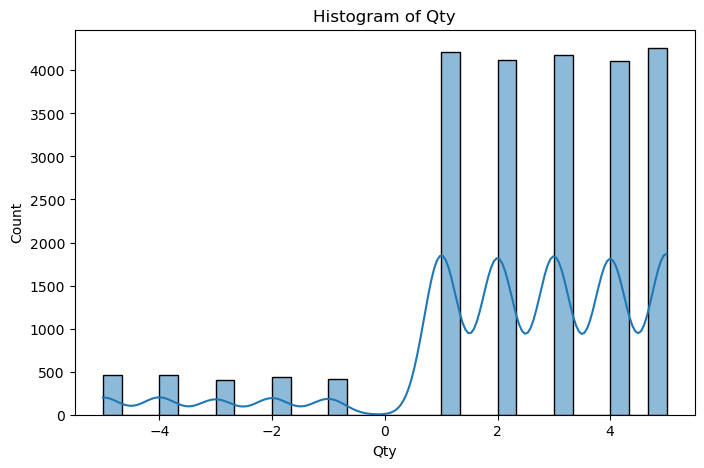

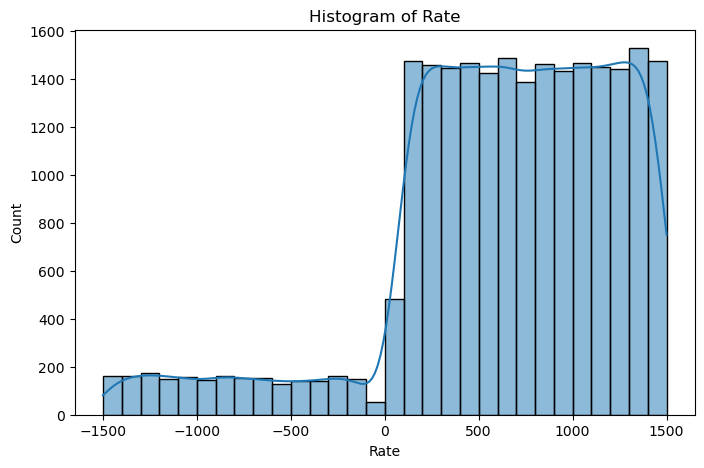

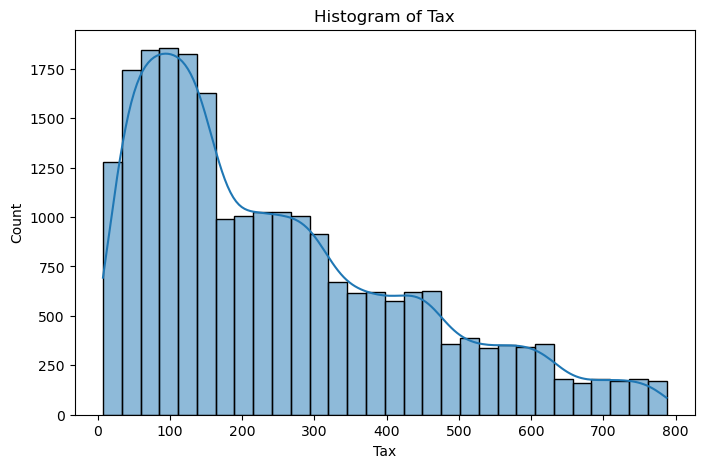

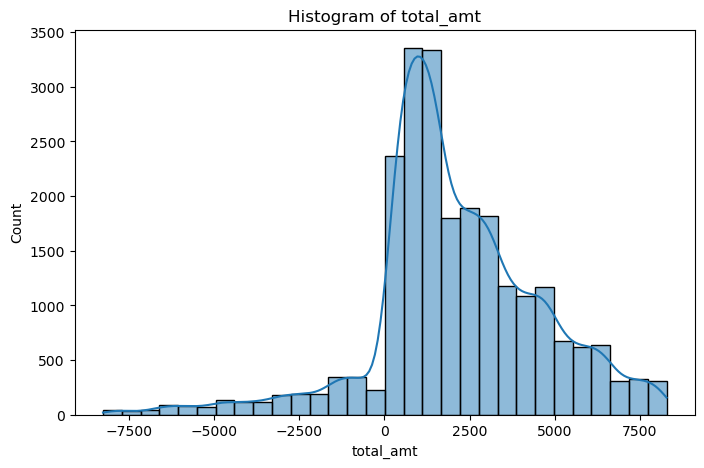

In [260]:
conti_var = ['Qty','Rate','Tax','total_amt']

for i in conti_var:
    plt.figure(figsize=(8,5))
    sns.histplot(customer_final[i],bins=30,kde=True)
    plt.title(f'Histogram of {i}')
    plt.show()

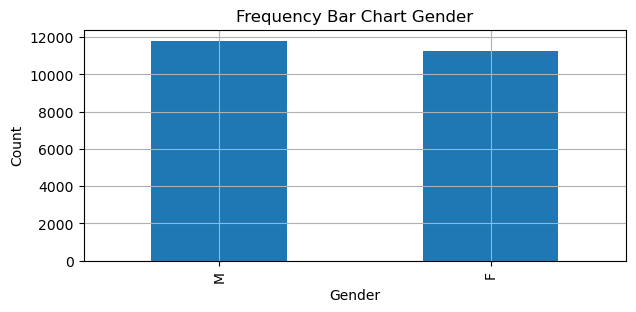

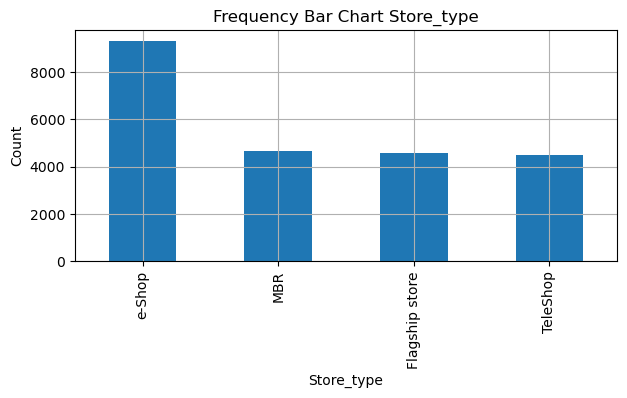

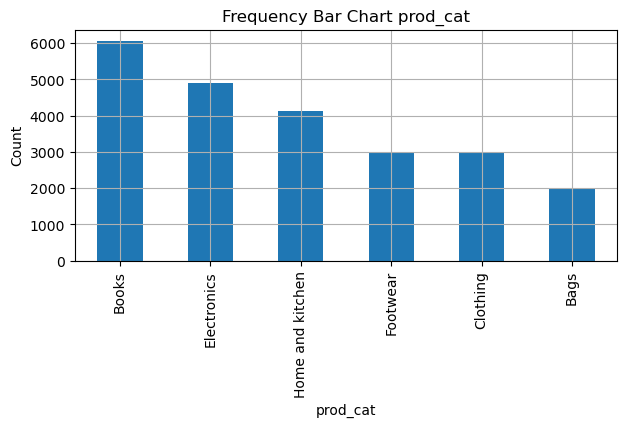

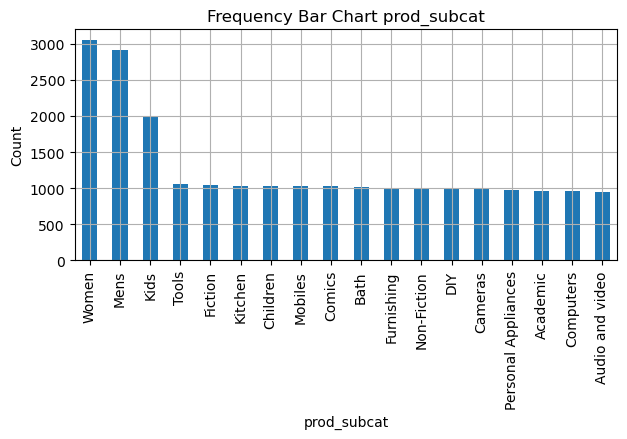

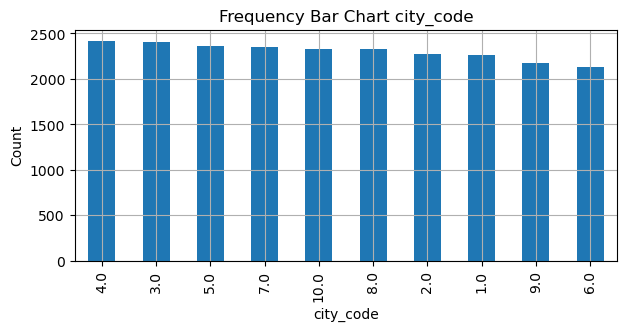

In [261]:
cate_var = ['Gender','Store_type','prod_cat','prod_subcat','city_code']

for i in cate_var:
    plt.figure(figsize=(7,3))
    customer_final[i].value_counts().plot(kind='bar')
    plt.grid()
    plt.title(f'Frequency Bar Chart {i}')
    plt.ylabel('Count')
    plt.show()

In [262]:
print('Start date :',customer_final.tran_date.min())
print('End Date :',customer_final.tran_date.max())
print('Total Days :',(customer_final['tran_date'].max() - customer_final['tran_date'].min()).days)
print('Total Approx Months :',(customer_final['tran_date'].max() - customer_final['tran_date'].min()).days / 30)
print('Total Years :',(customer_final['tran_date'].max() - customer_final['tran_date'].min()).days / 365.25)

Start date : 2011-01-25 00:00:00
End Date : 2014-02-28 00:00:00
Total Days : 1130
Total Approx Months : 37.666666666666664
Total Years : 3.0937713894592744


In [263]:
(customer_final['total_amt'] < 0).sum()

np.int64(2177)

In [264]:
customer_final.pivot_table(index = 'prod_cat', columns = 'Gender',values = 'Qty', aggfunc = 'count').sort_values(by = ['F','M'],ascending = False)
                                            # OR
# customer_final.groupby(['Gender','prod_cat'])['prod_cat'].value_counts()

Gender,F,M
prod_cat,,
Books,2949,3116
Electronics,2328,2570
Home and kitchen,1994,2134
Footwear,1529,1469
Clothing,1439,1518
Bags,994,1004


In [265]:
(customer_final.groupby('city_code')['customer_Id'].nunique().sort_values(ascending = False))

city_code
3.0     576
5.0     570
4.0     569
7.0     563
8.0     551
2.0     546
10.0    546
1.0     535
9.0     532
6.0     516
Name: customer_Id, dtype: int64

In [266]:
max_cust = customer_final.groupby('city_code')['customer_Id'].nunique() / customer_final.customer_Id.nunique() * 100
max_cust.sort_values(ascending = False)

city_code
3.0     10.461315
5.0     10.352343
4.0     10.334181
7.0     10.225209
8.0     10.007265
2.0      9.916455
10.0     9.916455
1.0      9.716673
9.0      9.662187
6.0      9.371595
Name: customer_Id, dtype: float64

In [267]:
sales = customer_final.groupby('Store_type')[['Qty','total_amt']].sum().sort_values(['Qty','total_amt'],ascending = False)
sales

,Qty,total_amt
Store_type,,
e-Shop,22763,1.982482e+07
MBR,11194,9.674486e+06
Flagship store,11133,9.715688e+06
TeleShop,10984,9.364781e+06


In [268]:
flagship = customer_final[customer_final['Store_type'] == 'Flagship store']
flagship = flagship[flagship['prod_cat'].isin(['Electronics','Clothing'])]
print('Total Amount Earned :',flagship['total_amt'].sum())
print('\n Category wise break down :')
print('\n',(customer_final.pivot_table(index = 'Store_type', columns = 'prod_cat', values = 'total_amt', aggfunc = 'sum')).loc['Flagship store',['Clothing','Electronics']])

Total Amount Earned : 3409559.27

 Category wise break down :

 prod_cat
Clothing       1194423.23
Electronics    2215136.04
Name: Flagship store, dtype: float64


In [269]:
(customer_final.pivot_table(index = 'Gender',columns = 'prod_cat',values = 'total_amt',aggfunc = 'sum')).loc['M','Electronics']

np.float64(5703109.425)

In [270]:
(customer_final[customer_final['total_amt']  > 0].groupby('customer_Id')['transaction_id'].nunique() > 10).sum()

np.int64(6)

In [271]:
customer_final['Age'] = dt.datetime.now().year  - (customer_final.DOB).dt.year


In [272]:
spec_age = customer_final[(customer_final['Age'] >= 25) & (customer_final['Age'] <= 35)]
spec_age.head()

,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat,customer_Id,DOB,Gender,city_code,Age
2,51750724947,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY,273420,1992-07-27,M,8.0,34
4,51750724947,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY,273420,1992-07-27,M,8.0,34
28,88853694830,2014-02-20,4,4,-3,-80,25.200,-265.200,MBR,Bags,Women,268444,1992-01-02,F,6.0,34
37,31384765864,2014-02-19,3,2,1,793,83.265,876.265,e-Shop,Footwear,Women,267058,1992-02-06,F,10.0,34
59,83313344780,2014-02-18,4,3,2,84,17.640,185.640,Flagship store,Electronics,Mobiles,271288,1991-02-25,F,3.0,35


In [273]:
(spec_age.groupby('prod_cat')['total_amt'].sum()).loc[['Books','Electronics']].sum()

np.float64(1938869.4649999999)

In [274]:
res_b = spec_age[(spec_age.tran_date >= '2014-01-01') & (spec_age.tran_date <= '2014-03-01')]
res_b['total_amt'].sum()

np.float64(228354.87999999998)

Text(0.5, 1.0, 'Gender Distribution')

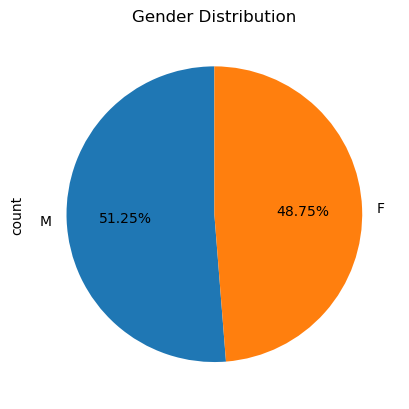

In [275]:
customer_final.Gender.value_counts().plot(kind = 'pie', autopct = '%1.2f%%',startangle = 90)
plt.title('Gender Distribution')

Text(0, 0.5, 'Quantity')

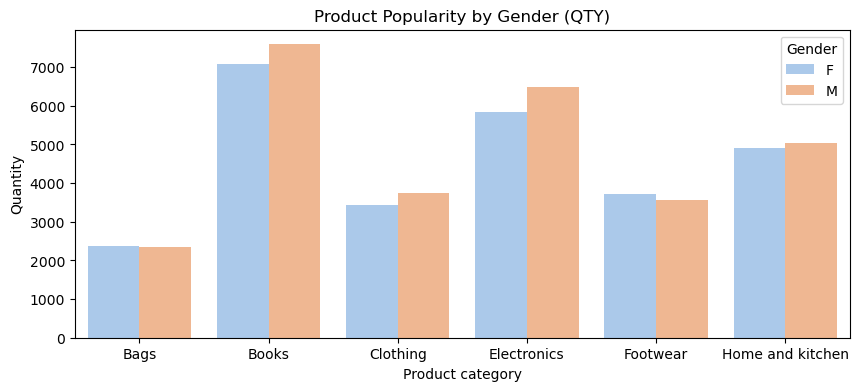

In [276]:
gender_sales = customer_final.groupby(['prod_cat','Gender'])['Qty'].sum().reset_index()

plt.figure(figsize=(10,4))
sns.barplot(gender_sales, x = 'prod_cat',y = 'Qty', hue = 'Gender', palette= 'pastel')

plt.title('Product Popularity by Gender (QTY)')
plt.xlabel('Product category')
plt.ylabel('Quantity')


Text(0, 0.5, 'Total_Revenue')

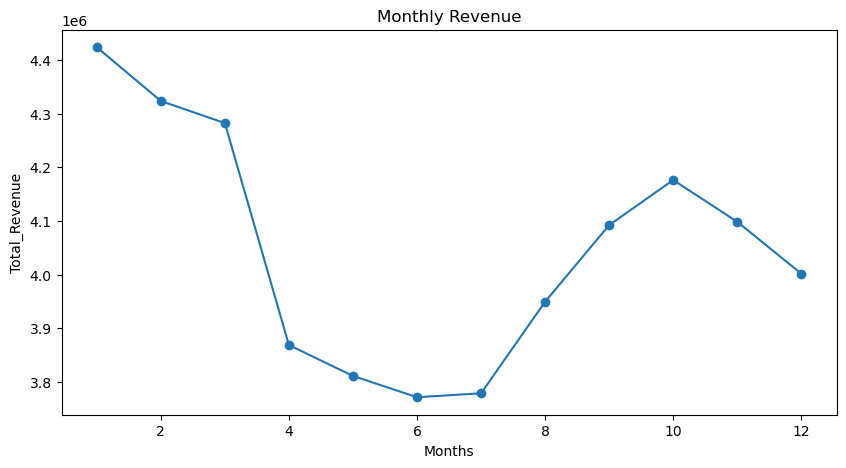

In [277]:
customer_final['Month'] = customer_final.tran_date.dt.month
monthly_rev = customer_final.groupby('Month')['total_amt'].sum()
monthly_rev.plot(kind = 'line',figsize = (10,5),marker = 'o')

plt.title('Monthly Revenue')
plt.xlabel('Months')
plt.ylabel('Total_Revenue')

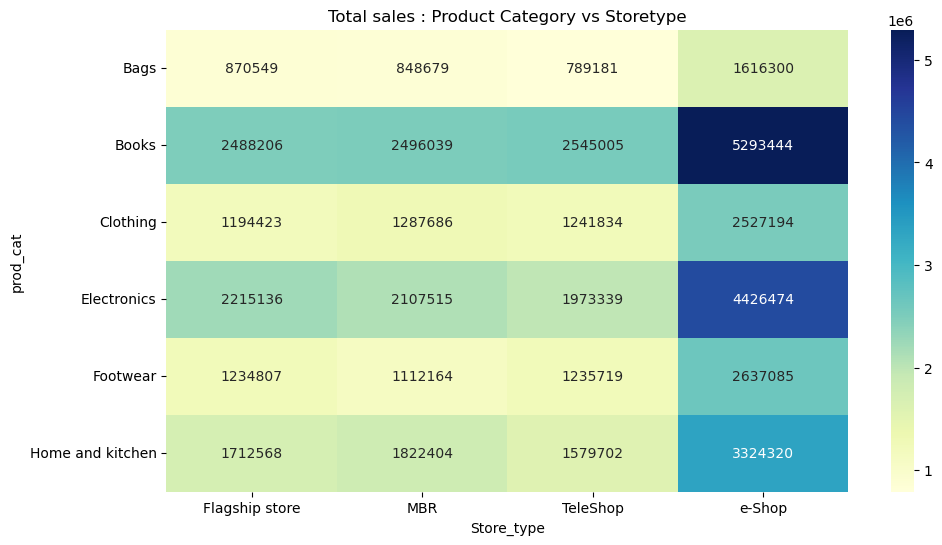

In [278]:
data = customer_final.groupby(['prod_cat','Store_type'])['total_amt'].sum().unstack(fill_value = 0)


plt.figure(figsize=(11,6))
sns.heatmap(data,annot = True, fmt = '.0f' , cmap = 'YlGnBu')
plt.title('Total sales : Product Category vs Storetype')
plt.show()

C:\Users\priyansh\AppData\Local\Temp\ipykernel_2620\125218829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_5_cities,palette = 'Set2')


Text(0.5, 1.0, 'Top 5 Cities by Number of Customers')

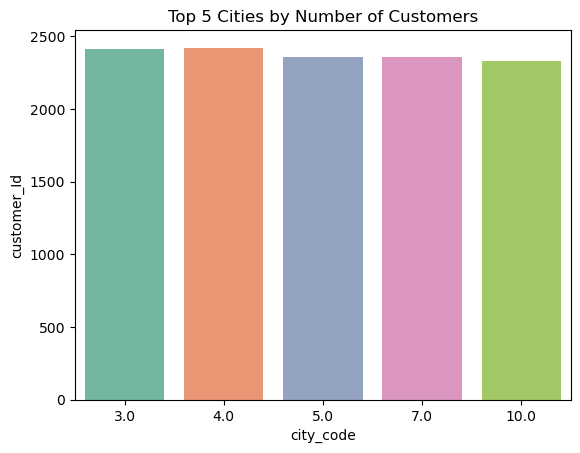

In [279]:
top_5_cities = customer_final.groupby('city_code')['customer_Id'].count().sort_values(ascending =  False).head()
sns.barplot(top_5_cities,palette = 'Set2')
plt.title('Top 5 Cities by Number of Customers')

Text(0, 0.5, 'Total number of customer')

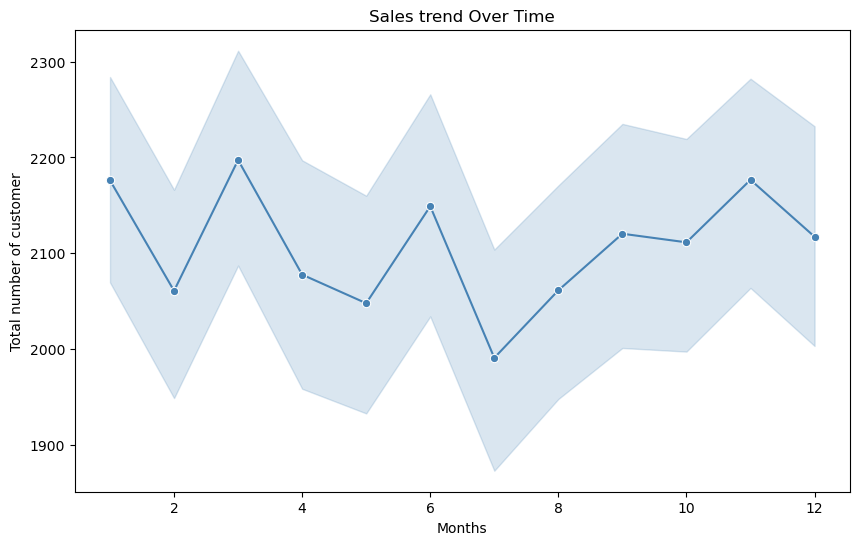

In [280]:
plt.figure(figsize=(10,6))
sns.lineplot(customer_final, x = 'Month', y = 'total_amt',marker = 'o', color = 'steelblue')
plt.title('Sales trend Over Time')
plt.xlabel('Months')
plt.ylabel('Total number of customer')